# Detecting and Removing Outliers using boxplot

In [81]:
lst = [1,2,3,4,5]

In [82]:
new_lst = []
for a in lst:
    new_lst.append(a*10)
new_lst    

[10, 20, 30, 40, 50]

In [83]:
import numpy as np
a = np.array(lst)
a*10

array([10, 20, 30, 40, 50])

In [84]:
import pandas as pd

In [85]:
data = pd.read_excel('emp.xlsx')
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000


In [86]:
import warnings
warnings.filterwarnings('ignore')

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [88]:
data.describe()

,Serial,Emp_ID,Age,Salary
count,26.000000,26.000000,26.000000,26.000000
mean,12.500000,2166.692308,35.000000,94173.913043
std,7.648529,1463.539074,9.549869,31627.395939
min,0.000000,1001.000000,23.000000,45000.000000
25%,6.250000,1108.000000,27.000000,89000.000000
50%,12.500000,2123.000000,30.500000,94173.913043
75%,18.750000,2156.000000,45.000000,100000.000000
max,25.000000,6543.000000,50.000000,200000.000000


In [101]:
from IPython.display import Image

# Pass the direct image URL into the function
Image(url="https://miro.medium.com/1*0MPDTLn8KoLApoFvI0P2vQ.png", width=500, height=600)


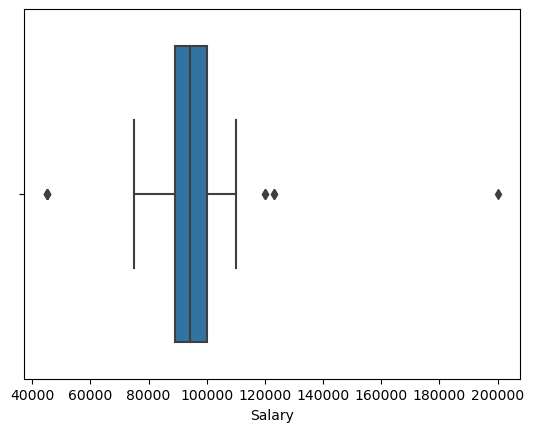

In [90]:
sns.boxplot(data.Salary)
plt.show()

In [91]:
q1 = np.percentile(data.Salary,25)
q1

89000.0

In [92]:
q3 = np.percentile(data.Salary,75)
q3

100000.0

In [93]:
iqr = q3-q1
iqr

11000.0

In [94]:
min_salary = q1-1.5*iqr
min_salary

72500.0

In [95]:
max_salary = q3+1.5*iqr
max_salary

116500.0

In [96]:
data[(data.Salary<min_salary) | (data.Salary>max_salary) ]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.0
3,3,1005,Manager,HR,45,120000.0
4,4,2123,Office Boy,Accounts,27,45000.0
11,11,3214,Accountant,Account,49,123000.0
17,17,2123,Office Boy,Accounts,27,45000.0
18,18,1005,Manager,HR,45,120000.0
19,19,2123,Office Boy,Accounts,27,45000.0
21,21,3214,Accountant,Account,49,123000.0
25,25,2123,Office Boy,Accounts,27,45000.0


In [97]:
def detect_outliers(col):
    q1 = np.percentile(col,25)
    q3 = np.percentile(col,75)
    iqr = q3-q1
    lower_boundary= q1-1.5*iqr
    upper_boundary= q3+1.5*iqr
    return lower_boundary,upper_boundary

In [98]:
detect_outliers(data.Salary)

(72500.0, 116500.0)

In [99]:
data[(data.Salary < detect_outliers(data.Salary)[0]) |(data.Salary > detect_outliers(data.Salary)[1])]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.0
3,3,1005,Manager,HR,45,120000.0
4,4,2123,Office Boy,Accounts,27,45000.0
11,11,3214,Accountant,Account,49,123000.0
17,17,2123,Office Boy,Accounts,27,45000.0
18,18,1005,Manager,HR,45,120000.0
19,19,2123,Office Boy,Accounts,27,45000.0
21,21,3214,Accountant,Account,49,123000.0
25,25,2123,Office Boy,Accounts,27,45000.0


In [119]:
data[(data.Salary > detect_outliers(data.Salary)[0]) & (data.Salary < detect_outliers(data.Salary)[1])]

,Emp_ID,Designation,Department,Age,Salary
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000
10,6543,Officer,Production,29,100000.000000
11,3214,Accountant,Account,49,123000.000000


In [103]:
data[data.Salary>detect_outliers(data.Salary)[0]]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000
10,10,6543,Officer,Production,29,100000.000000


In [104]:
data[data.Salary<detect_outliers(data.Salary)[0]]

,Serial,Emp_ID,Designation,Department,Age,Salary
4,4,2123,Office Boy,Accounts,27,45000.0
17,17,2123,Office Boy,Accounts,27,45000.0
19,19,2123,Office Boy,Accounts,27,45000.0
25,25,2123,Office Boy,Accounts,27,45000.0


#### Duplicate Data Detection and Removal

In [106]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000


In [107]:
data.drop('Serial',axis=1,inplace=True)

In [109]:
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


In [108]:
data.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12     True
13    False
14    False
15    False
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24     True
25     True
dtype: bool

In [110]:
data[data.duplicated()]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45,89000.0
16,2156,Engineer,Production,45,89000.0
17,2123,Office Boy,Accounts,27,45000.0
18,1005,Manager,HR,45,120000.0
19,2123,Office Boy,Accounts,27,45000.0
20,6543,Officer,Production,29,100000.0
21,3214,Accountant,Account,49,123000.0
22,2156,Engineer,Production,45,89000.0
23,1098,Officer,IT,25,100000.0
24,2156,Engineer,Production,45,89000.0


In [111]:
data.drop_duplicates()

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


In [114]:
data[data.duplicated(subset=['Designation','Salary'])]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45,89000.000000
13,1098,Officer,IT,25,100000.000000
15,1222,Officer,Production,25,94173.913043
16,2156,Engineer,Production,45,89000.000000
17,2123,Office Boy,Accounts,27,45000.000000
18,1005,Manager,HR,45,120000.000000
19,2123,Office Boy,Accounts,27,45000.000000
20,6543,Officer,Production,29,100000.000000
21,3214,Accountant,Account,49,123000.000000
22,2156,Engineer,Production,45,89000.000000


In [115]:
data.drop_duplicates(inplace=True)

In [116]:
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


#### Tranforming a data using a function or mapping

In [120]:
emp = pd.read_excel('employee28.xlsx')

In [121]:
emp

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,man,Accounts,50.0,200000.0
1,1,1107,off,IT,30.0,80000.0
2,2,1203,off,HR,28.0,NaN
3,3,1005,man,HR,45.0,120000.0
4,4,2123,ofb,Accounts,27.0,45000.0
5,5,2451,acnt,NaN,34.0,100000.0
6,6,1111,acnt,Accounts,NaN,110000.0
7,7,1001,off,IT,25.0,75000.0
8,8,1234,man,IT,23.0,NaN
9,9,2156,eng,Production,45.0,89000.0


In [122]:
from IPython.display import Image

Image(url="https://upload.wikimedia.org/wikipedia/commons/f/fa/Michelsonmorley-boxplot.svg")

In [123]:
mapping = {'man':'Manager', 'off':'Officer','ofb':'Office Boy','acnt':'Accountant', 'eng':'Engineer'}

In [ ]:

emp['full_designation'] = emp.Designation.map(mapping)